# Lapsed Donor Reactivation Analysis

Identifies consistent givers who stopped donating within the past five years,
with special attention to donors who gave **$250 or more** in at least one year.


In [1]:
import csv
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import create_engine, text

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_DIR = Path.cwd()
FIGURE_DIR  = PROJECT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

ENGINE = create_engine(
    "postgresql+psycopg2://liml@localhost/arizona_list",
    connect_args={"client_encoding": "utf8"},
)
LAPSED_CSV         = PROJECT_DIR / "lapsed_consistent_donors.csv"
LAPSED_250PLUS_CSV = PROJECT_DIR / "lapsed_consistent_donors_250plus.csv"
POSTCARD_CSV       = PROJECT_DIR / "people_added_since_january_postcard_outreach.csv"

# ── Parameters ────────────────────────────────────────────────────────────────
ANALYSIS_DATE    = "2026-04-16"
POSTCARD_START   = "2026-01-01"
MIN_GIVING_YEARS = 3
MIN_STREAK_YEARS = 3
HIGH_VALUE       = 250

# ── Helpers ───────────────────────────────────────────────────────────────────
def run(sql):
    with ENGINE.connect() as conn:
        return [dict(r._mapping) for r in conn.execute(text(sql))]

def one(sql):
    return run(sql)[0]

def save_csv(path, rows, cols):
    with path.open("w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=cols)
        w.writeheader()
        for row in rows:
            w.writerow({c: row.get(c, "") for c in cols})

def md_table(rows, cols):
    header = "| " + " | ".join(cols) + " |"
    sep    = "| " + " | ".join("---" for _ in cols) + " |"
    body   = ["| " + " | ".join(str(row.get(c, "")) for c in cols) + " |" for row in rows]
    return "\n".join([header, sep, *body])


## 1. Data Check

In [2]:
data_check = one("""
    SELECT COUNT(*)                  AS contribution_rows,
           COUNT(DISTINCT co.vanid)  AS distinct_donors,
           MIN(co.date_received)     AS first_gift,
           MAX(co.date_received)     AS latest_gift
    FROM contributions co
    JOIN contacts c ON co.vanid = c.vanid
""")
print(data_check)


{'contribution_rows': 53020, 'distinct_donors': 7769, 'first_gift': datetime.date(2004, 1, 15), 'latest_gift': datetime.date(2026, 4, 9)}


## 2. Donor Universe vs. Leadership Council

Leadership Council membership is identified from three signals, deduplicated:
- Activist codes `19LCPin` and `20LCPin`
- Contribution `source_code` containing "LC"
- Online action `source_code` containing "LC"


{'total_donors': 7769, 'lc_members': 386, 'lc_pct_of_donors': Decimal('5.0')}


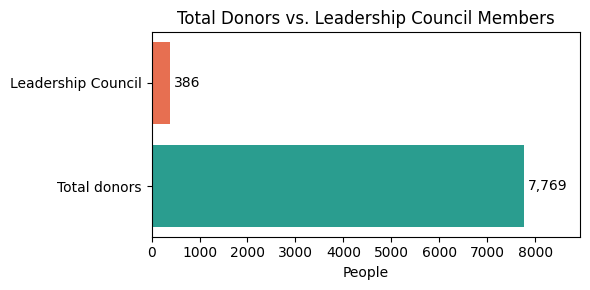

In [3]:
donor_vs_lc = one("""
    WITH lc_members AS (
        SELECT vanid FROM activist_codes_applied WHERE activist_code_name IN ('19LCPin', '20LCPin')
        UNION
        SELECT vanid FROM contributions WHERE lower(source_code) LIKE '%lc%'
        UNION
        SELECT vanid FROM online_actions WHERE lower(source_code) LIKE '%lc%'
    )
    SELECT
        (SELECT COUNT(DISTINCT vanid) FROM contributions WHERE amount > 0) AS total_donors,
        COUNT(DISTINCT vanid)                                               AS lc_members,
        ROUND(100.0 * COUNT(DISTINCT vanid) /
              (SELECT COUNT(DISTINCT vanid) FROM contributions WHERE amount > 0), 1) AS lc_pct_of_donors
    FROM lc_members
""")
print(donor_vs_lc)

fig, ax = plt.subplots(figsize=(6, 3))
labels = ["Total donors", "Leadership Council"]
values = [donor_vs_lc["total_donors"], donor_vs_lc["lc_members"]]
bars = ax.barh(labels, values, color=["#2a9d8f", "#e76f51"])
for bar, v in zip(bars, values):
    ax.text(bar.get_width() + max(values) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{v:,}", va="center")
ax.set_xlabel("People")
ax.set_title("Total Donors vs. Leadership Council Members")
ax.set_xlim(0, max(values) * 1.15)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "donor_vs_leadership_council.svg", bbox_inches="tight")
plt.show()

## 3. Mail-Reachable People Without an Email Address

**Complete address** = non-empty street, city, state, zip.  
**No email** = both `preferredemail` and `otheremail` are empty.  
**Mailable** = complete address + no email + `nomail = 0`.


{'total_people': 79830, 'with_address': 54703, 'no_email': 19319, 'mailable_no_email': 16440}


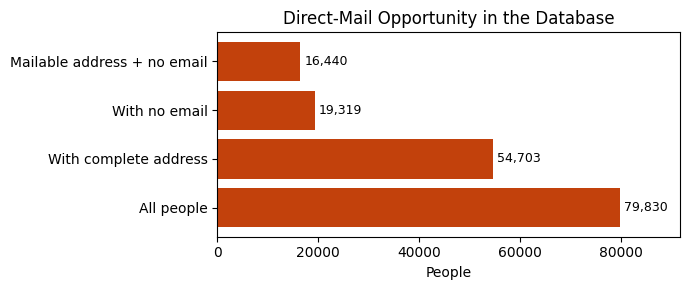

In [4]:
mail_no_email = one("""
    SELECT
        COUNT(*)                                        AS total_people,
        COUNT(*) FILTER (WHERE EXISTS (
            SELECT 1 FROM addresses a
            WHERE a.vanid = c.vanid
              AND a.is_best_address    = TRUE
              AND a.is_complete_address = TRUE
        ))                                              AS with_address,
        COUNT(*) FILTER (WHERE
            c.preferred_email IS NULL
            AND c.other_email IS NULL
        )                                               AS no_email,
        COUNT(*) FILTER (WHERE EXISTS (
            SELECT 1 FROM addresses a
            WHERE a.vanid = c.vanid
              AND a.is_best_address     = TRUE
              AND a.is_complete_address = TRUE
        )
        AND c.preferred_email IS NULL
        AND c.other_email     IS NULL
        AND c.no_mail         IS NOT TRUE
        )                                               AS mailable_no_email
    FROM contacts c
    WHERE c.type_of_contact = 'Person'
""")
print(mail_no_email)

fig, ax = plt.subplots(figsize=(7, 3))
labels = ["All people", "With complete address", "With no email", "Mailable address + no email"]
values = [mail_no_email["total_people"], mail_no_email["with_address"],
          mail_no_email["no_email"],     mail_no_email["mailable_no_email"]]
bars = ax.barh(labels, values, color="#c2410c")
for bar, v in zip(bars, values):
    ax.text(bar.get_width() + max(values) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{v:,}", va="center", fontsize=9)
ax.set_xlabel("People")
ax.set_title("Direct-Mail Opportunity in the Database")
ax.set_xlim(0, max(values) * 1.15)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "mailing_no_email_opportunity.svg", bbox_inches="tight")
plt.show()


## 4. Postcard Candidates Added Since January

People added since `{POSTCARD_START}` who have a complete mailing address,
no email on file, and `nomail = 0`.


In [5]:
postcard_rows = run(f"""
    SELECT
        c.vanid,
        TRIM(COALESCE(c.last,'')
            || CASE WHEN TRIM(COALESCE(c.first,'')) <> '' THEN ', ' || TRIM(c.first) ELSE '' END)
                                    AS contact_name,
        a.street_address            AS address,
        a.city,
        a.state                     AS state_province,
        a.zip                       AS zip_postal,
        c.date_created,
        c.origin_code_name          AS origincodename
    FROM contacts c
    JOIN addresses a ON c.vanid = a.vanid AND a.is_preferred = TRUE
    WHERE c.type_of_contact = 'Person'
      AND c.date_created >= '{POSTCARD_START}'
      AND TRIM(COALESCE(a.street_address,'')) <> ''
      AND TRIM(COALESCE(a.city,''))           <> ''
      AND TRIM(COALESCE(a.state,''))          <> ''
      AND TRIM(COALESCE(a.zip,''))            <> ''
      AND TRIM(COALESCE(c.preferred_email,'')) = ''
      AND TRIM(COALESCE(c.other_email,''))    = ''
      AND (c.no_mail = FALSE OR c.no_mail IS NULL)
    ORDER BY c.date_created DESC, c.last
""")

save_csv(POSTCARD_CSV, postcard_rows,
    ["vanid","contact_name","address","city","state_province","zip_postal","date_created","origincodename"])

print(f"{len(postcard_rows)} postcard candidates — saved to {POSTCARD_CSV.name}")
print(md_table(postcard_rows, ["vanid","contact_name","city","state_province","date_created","origincodename"]))


6 postcard candidates — saved to people_added_since_january_postcard_outreach.csv


| vanid | contact_name | city | state_province | date_created | origincodename |
| --- | --- | --- | --- | --- | --- |
| 131942803 | Calderone, Dawna | Phoenix | AZ | 2026-03-30 | 26Sponsor |
| 131448005 | Melendez, Deanna | Prescott | AZ | 2026-02-26 | 2023 Direct Mail |
| 131448040 | Movahed, Reza | Tucson | AZ | 2026-02-26 | None |
| 130742680 | Bradford Coleman, Karyn | Little Rock | AR | 2026-01-19 | None |
| 130742681 | Figuroa, Lauren | Peoria | AZ | 2026-01-19 | None |
| 130742679 | Jewel, Jasmine | Flagstaff | AZ | 2026-01-19 | None |


## 5. Lapsed Donor Identification

**Consistent** = ≥ 3 distinct giving years **and** longest consecutive streak ≥ 3 years.  
**Lapsed** = last gift between 1 and 5 years before the analysis date.  
**High-value** = at least one year with annual giving ≥ $250.

Streak detection uses the gaps-and-islands pattern:
`gift_year − ROW_NUMBER()` is constant within any unbroken run of years.

| Tier | Meaning |
|------|---------|
| Tier 1 | High-value ($250+) and lapsed within the last 2 years |
| Tier 2 | High-value ($250+) and lapsed 2–5 years ago |
| Tier 3 | Not high-value, lapsed within 2 years |
| Tier 4 | Not high-value, lapsed 2–5 years ago |


In [6]:
candidates = run(f"""
WITH yearly_giving AS (
    -- One row per donor per year: aggregate all gifts in that calendar year.
    SELECT
        co.vanid,
        EXTRACT(YEAR FROM co.date_received)::INT  AS gift_year,
        SUM(co.amount)                            AS year_total,
        COUNT(*)                                  AS gift_count,
        MAX(co.date_received)                     AS last_gift_date,
        MAX(co.amount)                            AS largest_single_gift
    FROM contributions co
    JOIN contacts c ON co.vanid = c.vanid
    WHERE c.type_of_contact = 'Person'
      AND co.amount > 0
    GROUP BY co.vanid, EXTRACT(YEAR FROM co.date_received)::INT

), donor_stats AS (
    -- Lifetime summary per donor, across all years.
    SELECT
        vanid,
        COUNT(*)                                           AS giving_years,
        MIN(gift_year)                                     AS first_gift_year,
        MAX(gift_year)                                     AS last_gift_year,
        SUM(year_total)                                    AS lifetime_amount,
        AVG(year_total)                                    AS avg_annual_amount,
        MAX(year_total)                                    AS max_annual_amount,
        MAX(largest_single_gift)                           AS max_single_gift,
        SUM(gift_count)                                    AS lifetime_gifts,
        COUNT(*) FILTER (WHERE year_total >= {HIGH_VALUE}) AS years_at_high_value,
        MAX(last_gift_date)                                AS last_gift_date
    FROM yearly_giving
    GROUP BY vanid

), streak_stats AS (
    -- Longest consecutive giving streak per donor using gaps-and-islands.
    -- gift_year - ROW_NUMBER() is constant within any unbroken run of years.
    SELECT vanid, MAX(run_length) AS longest_streak
    FROM (
        SELECT vanid, COUNT(*) AS run_length
        FROM (
            SELECT vanid, gift_year,
                   gift_year - ROW_NUMBER() OVER (PARTITION BY vanid ORDER BY gift_year) AS island
            FROM yearly_giving
        ) islands
        GROUP BY vanid, island
    ) runs
    GROUP BY vanid
)

SELECT
    ds.vanid,
    TRIM(COALESCE(c.last, '') ||
         CASE WHEN TRIM(COALESCE(c.first, '')) <> '' THEN ', ' || TRIM(c.first) ELSE '' END)
                                                AS contact_name,
    ds.giving_years,
    COALESCE(ss.longest_streak, 1)             AS longest_streak,
    ds.first_gift_year,
    ds.last_gift_year,
    ds.last_gift_date,
    ('{ANALYSIS_DATE}'::date - ds.last_gift_date::date)
                                               AS days_since_last_gift,
    ROUND(ds.lifetime_amount::numeric,    2)   AS lifetime_amount,
    ROUND(ds.avg_annual_amount::numeric,  2)   AS avg_annual_amount,
    ROUND(ds.max_annual_amount::numeric,  2)   AS max_annual_amount,
    ROUND(ds.max_single_gift::numeric,    2)   AS max_single_gift_amount,
    ds.lifetime_gifts,
    ds.years_at_high_value,
    (ds.years_at_high_value >= 1)::int         AS priority_250_plus,
    CASE
        WHEN ds.years_at_high_value >= 1
             AND ds.last_gift_date >= '{ANALYSIS_DATE}'::date - INTERVAL '2 years' THEN 'Tier 1'
        WHEN ds.years_at_high_value >= 1                                            THEN 'Tier 2'
        WHEN ds.last_gift_date      >= '{ANALYSIS_DATE}'::date - INTERVAL '2 years' THEN 'Tier 3'
        ELSE                                                                              'Tier 4'
    END AS recapture_priority

FROM donor_stats ds
JOIN contacts c ON ds.vanid = c.vanid
LEFT JOIN streak_stats ss ON ss.vanid = ds.vanid

WHERE ds.giving_years                  >= {MIN_GIVING_YEARS}
  AND COALESCE(ss.longest_streak, 1)   >= {MIN_STREAK_YEARS}
  AND ds.last_gift_date <= '{ANALYSIS_DATE}'::date - INTERVAL '1 year'
  AND ds.last_gift_date >  '{ANALYSIS_DATE}'::date - INTERVAL '5 years'

ORDER BY priority_250_plus DESC, last_gift_date DESC, years_at_high_value DESC, max_annual_amount DESC
""")

print(f"{len(candidates):,} candidates found.")


352 candidates found.


## 6. Summary and Priority Results

Total candidates:   352
  $250+ history:    209
  Tier 1:           85
  Tier 2:           124
  Tier 3:           54
  Tier 4:           89
Avg giving years:   7.4
Avg longest streak: 5.3
Avg lifetime amt:   $3,044

Last gift year | Candidates
  2025           | 69
  2024           | 101
  2023           | 90
  2022           | 52
  2021           | 40


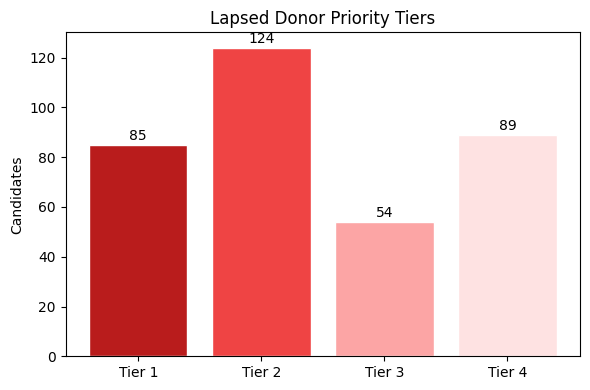


| contact_name | recapture_priority | giving_years | longest_streak | last_gift_date | lifetime_amount | max_annual_amount |
| --- | --- | --- | --- | --- | --- | --- |
| Scheel, Benjamin | Tier 1 | 11 | 11 | 2025-04-16 | 1390.00 | 260.00 |
| Sensibar, Judy | Tier 1 | 8 | 4 | 2025-04-11 | 3141.06 | 1000.00 |
| Jamieson, Deboah | Tier 1 | 8 | 5 | 2025-04-06 | 1850.00 | 500.00 |
| Young, Harriet | Tier 1 | 20 | 16 | 2025-04-04 | 20283.32 | 2508.32 |
| Howard, Lucia | Tier 1 | 14 | 7 | 2025-04-04 | 4663.45 | 1353.45 |
| Benatar, Sarah | Tier 1 | 5 | 3 | 2025-03-28 | 757.19 | 500.00 |
| Bechtol, Vanessa | Tier 1 | 5 | 5 | 2025-03-28 | 706.90 | 353.45 |
| Ward, Dorothy | Tier 1 | 7 | 4 | 2025-03-17 | 1100.00 | 510.00 |
| Quackenbush, LiAnne | Tier 1 | 5 | 3 | 2025-03-15 | 5799.15 | 3250.00 |
| Green, Miles | Tier 1 | 4 | 3 | 2025-03-07 | 600.00 | 300.00 |
| Davis, Lynn | Tier 1 | 7 | 6 | 2025-03-06 | 1611.01 | 426.01 |
| Hatfield, Linda | Tier 1 | 14 | 8 | 2025-03-06 | 1320.00 | 260.00 |
|

In [7]:
tier_counts = Counter(r["recapture_priority"] for r in candidates)
n = len(candidates)

print(f"Total candidates:   {n:,}")
print(f"  $250+ history:    {sum(r['priority_250_plus'] for r in candidates):,}")
print(f"  Tier 1:           {tier_counts['Tier 1']:,}")
print(f"  Tier 2:           {tier_counts['Tier 2']:,}")
print(f"  Tier 3:           {tier_counts['Tier 3']:,}")
print(f"  Tier 4:           {tier_counts['Tier 4']:,}")
print(f"Avg giving years:   {sum(r['giving_years'] for r in candidates)/n:.1f}")
print(f"Avg longest streak: {sum(r['longest_streak'] for r in candidates)/n:.1f}")
print(f"Avg lifetime amt:   ${sum(r['lifetime_amount'] for r in candidates)/n:,.0f}")

# Last-gift-year breakdown
year_counts = Counter(r["last_gift_year"] for r in candidates)
print()
print("Last gift year | Candidates")
for yr in sorted(year_counts, reverse=True):
    print(f"  {yr}           | {year_counts[yr]:,}")

# Bar chart by tier
fig, ax = plt.subplots(figsize=(6, 4))
tiers  = ["Tier 1", "Tier 2", "Tier 3", "Tier 4"]
counts = [tier_counts[t] for t in tiers]
colors = ["#b91c1c", "#ef4444", "#fca5a5", "#fee2e2"]
bars = ax.bar(tiers, counts, color=colors, edgecolor="white")
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val), ha="center")
ax.set_ylabel("Candidates")
ax.set_title("Lapsed Donor Priority Tiers")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig(FIGURE_DIR / "lapsed_donor_priority_tiers.svg", bbox_inches="tight")
plt.show()

# Top 20 preview
print()
print(md_table(candidates[:20], [
    "contact_name", "recapture_priority", "giving_years", "longest_streak",
    "last_gift_date", "lifetime_amount", "max_annual_amount",
]))


## 7. CSV Exports

In [8]:
EXPORT_COLS = [
    "vanid", "contact_name", "recapture_priority", "priority_250_plus",
    "giving_years", "longest_streak", "first_gift_year", "last_gift_year",
    "last_gift_date", "days_since_last_gift", "lifetime_gifts",
    "lifetime_amount", "avg_annual_amount", "max_annual_amount",
    "max_single_gift_amount", "years_high_value",
]

save_csv(LAPSED_CSV,         candidates,                                    EXPORT_COLS)
save_csv(LAPSED_250PLUS_CSV, [r for r in candidates if r["priority_250_plus"]==1], EXPORT_COLS)

print(f"Saved {len(candidates):,} rows            → {LAPSED_CSV.name}")
print(f"Saved {sum(r['priority_250_plus'] for r in candidates):,} $250+ rows  → {LAPSED_250PLUS_CSV.name}")
print(f"Saved {len(postcard_rows):,} postcard rows → {POSTCARD_CSV.name}")


Saved 352 rows            → lapsed_consistent_donors.csv
Saved 209 $250+ rows  → lapsed_consistent_donors_250plus.csv
Saved 6 postcard rows → people_added_since_january_postcard_outreach.csv
